<a href="https://colab.research.google.com/github/D10sanp/3D-Avatar/blob/main/2D_3D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision torchaudio transformers timm matplotlib pillow opencv-python trimesh plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 736.5/736.5 kB 20.0 MB/s eta 0:00:00


In [ ]:
import torch
from transformers import GLPNImageProcessor, GLPNForDepthEstimation
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import cv2
import trimesh
from google.colab import files

In [ ]:
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
print("Using image:", image_path)

Saving Screenshot 2025-10-10 193000.png to Screenshot 2025-10-10 193000.png
Using image: Screenshot 2025-10-10 193000.png


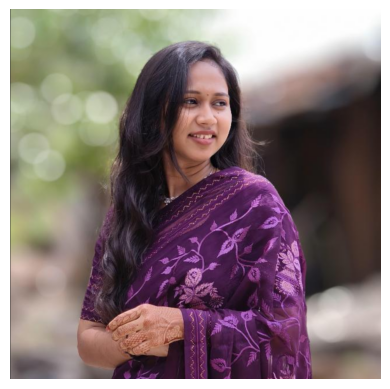

In [ ]:
image = Image.open(image_path).convert("RGB")
plt.imshow(image)
plt.axis("off")
plt.show()


In [ ]:
processor = GLPNImageProcessor.from_pretrained("vinvino02/glpn-nyu")
model = GLPNForDepthEstimation.from_pretrained("vinvino02/glpn-nyu")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/920 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/245M [00:00<?, ?B/s]

In [ ]:
new_height = 480
new_width = int(new_height * image.width / image.height)
img_resized = image.resize((new_width, new_height))


In [ ]:
inputs = processor(images=img_resized, return_tensors="pt")
with torch.no_grad():
    outputs = model(**inputs)
depth = outputs.predicted_depth.squeeze().cpu().numpy()


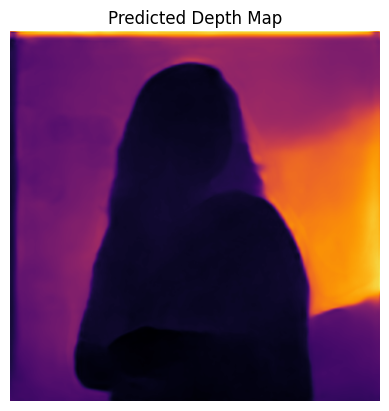

In [ ]:
depth_min, depth_max = depth.min(), depth.max()
depth_norm = (depth - depth_min) / (depth_max - depth_min)

plt.imshow(depth_norm, cmap='inferno')
plt.title("Predicted Depth Map")
plt.axis("off")
plt.show()

In [ ]:
rgb = np.array(img_resized) / 255.0
h, w = z.shape  # ensure same shape
y, x = np.meshgrid(np.arange(h), np.arange(w))
z = depth_norm

NameError: name 'z' is not defined

In [ ]:
# Ensure z matches RGB image size
z = cv2.resize(z, (rgb.shape[1], rgb.shape[0]))

h, w = z.shape

# Create meshgrid of x, y
y, x = np.meshgrid(np.arange(h), np.arange(w))

# Now all arrays have the same shape
vertices = np.stack([x.flatten(), -y.flatten(), z.flatten()], axis=-1)

# Flatten RGB colors
colors = rgb.reshape(-1, 3)

faces = []
for i in range(h - 1):
    for j in range(w - 1):
        v1 = i * w + j
        v2 = v1 + 1
        v3 = v1 + w
        v4 = v3 + 1
        faces.append([v1, v3, v2])
        faces.append([v2, v3, v4])
faces = np.array(faces)

mesh = trimesh.Trimesh(vertices=vertices, faces=faces, vertex_colors=colors)


In [ ]:
fig = go.Figure(data=[go.Mesh3d(
    x=vertices[:,0],
    y=vertices[:,1],
    z=vertices[:,2],
    i=faces[:,0],
    j=faces[:,1],
    k=faces[:,2],
    vertexcolor=["rgb(%d,%d,%d)" % tuple((c*255).astype(int)) for c in colors],
    lighting=dict(ambient=0.6, diffuse=0.9)
)])
fig.update_layout(
    title="3D Model with Original Colors",
    scene=dict(xaxis=dict(visible=False), yaxis=dict(visible=False), zaxis=dict(visible=False))
)
fig.show()

In [ ]:
import trimesh

# Build vertex and face arrays
vertices = np.stack([x.flatten(), y.flatten(), z.flatten()], axis=-1)
faces = []

for i in range(h - 1):
    for j in range(w - 1):
        v1 = i * w + j
        v2 = v1 + 1
        v3 = v1 + w
        v4 = v3 + 1
        faces.append([v1, v3, v2])
        faces.append([v2, v3, v4])

faces = np.array(faces)
mesh = trimesh.Trimesh(vertices=vertices, faces=faces)

In [ ]:
mesh.export("output_model.obj")
print("✅ 3D model saved as output_model.obj")

In [ ]:
from google.colab import files
files.download("output_model.obj")